In [1]:
import torch
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

X = torch.arange(1, 11, dtype=torch.float32).reshape(-1, 1)

y = 2 * X + 1

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([10, 1])
y shape: torch.Size([10, 1])


In [3]:
model = nn.Linear(1, 1)

print("Параметри до навчання")
print("Weight:", model.weight.item())
print("Bias:", model.bias.item())

Параметри до навчання
Weight: 0.7645385265350342
Bias: 0.8300079107284546


In [4]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [11]:
history = []

epochs = 200

for epoch in range(epochs):

    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    history.append({
        "epoch": epoch + 1,
        "loss": loss.item(),
        "weight": model.weight.item(),
        "bias": model.bias.item()
    })

In [6]:
history_df = pd.DataFrame(history)

display(history_df.head())

display(history_df.tail())

,epoch,loss,weight,bias
0,1,61.104156,1.734543,0.969308
1,2,2.803555,1.942321,0.999123
2,3,0.128642,1.986830,1.005485
3,4,0.005913,1.996368,1.006824
4,5,0.000282,1.998414,1.007087


,epoch,loss,weight,bias
195,196,0.000002,1.999539,1.003208
196,197,0.000002,1.999541,1.003195
197,198,0.000002,1.999543,1.003181
198,199,0.000002,1.999545,1.003168
199,200,0.000002,1.999547,1.003155


In [7]:
print("Параметри після навчання")

print("Weight:", model.weight.item())

print("Bias:", model.bias.item())

Параметри після навчання
Weight: 1.9995468854904175
Bias: 1.0031547546386719


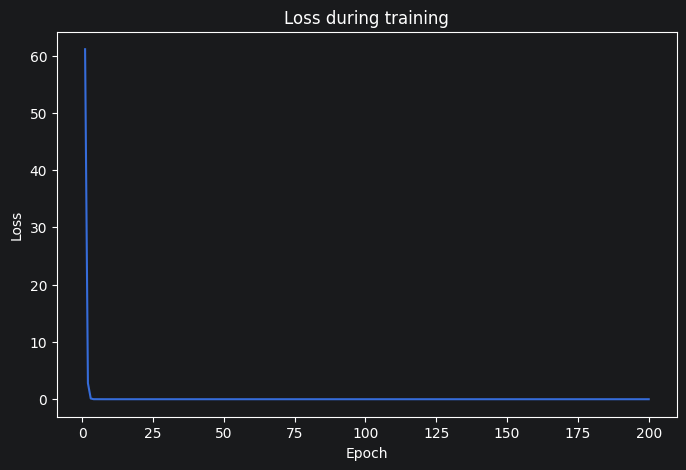

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history_df["epoch"], history_df["loss"])

plt.title("Loss during training")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

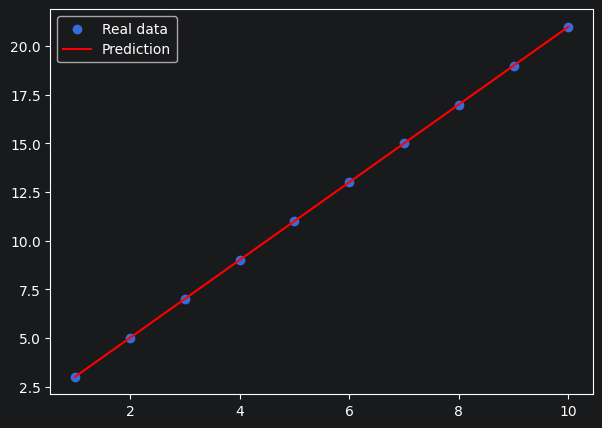

In [9]:
with torch.no_grad():
    predictions = model(X)

plt.figure(figsize=(7,5))

plt.scatter(X.numpy(), y.numpy(), label="Real data")

plt.plot(X.numpy(), predictions.numpy(), color="red", label="Prediction")

plt.legend()

plt.show()

In [10]:
comparison = pd.DataFrame({
    "Parameter": ["Weight", "Bias"],
    "Expected": [2, 1],
    "Learned": [
        model.weight.item(),
        model.bias.item()
    ]
})

display(comparison.round(4))

,Parameter,Expected,Learned
0,Weight,2,1.9995
1,Bias,1,1.0032


Під час навчання значення loss поступово зменшувалося, що свідчить про успішне навчання моделі. Отримані значення weight і bias наблизилися до очікуваних коефіцієнтів лінійної залежності y = 2x + 1. Побудовані графіки показали, що прогноз моделі майже повністю збігається з реальними даними.